<a href="https://colab.research.google.com/github/somar9/Neutrino-Oscillation-Project/blob/ND-simulation---Gaussian/Improved%3F.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [7]:

#Clone github repository for neutrino oscilation probability
!git clone https://github.com/mbustama/NuOscProbExact.git
%cd NuOscProbExact/src
%ls

Cloning into 'NuOscProbExact'...
remote: Enumerating objects: 615, done.
remote: Counting objects: 100% (29/29), done.
remote: Compressing objects: 100% (18/18), done.
remote: Total 615 (delta 13), reused 20 (delta 10), pack-reused 586 (from 1)
Receiving objects: 100% (615/615), 764.37 KiB | 4.58 MiB/s, done.
Resolving deltas: 100% (291/291), done.
/content/NuOscProbExact/src
globaldefs.py  hamiltonians2nu.py  hamiltonians3nu.py  oscprob2nu.py  oscprob3nu.py


In [8]:

import sys
sys.path.append('/path/to/NuOscProbExact/src')


In [9]:
from NuOscProbExact.src.oscprob3nu import probabilities_3nu


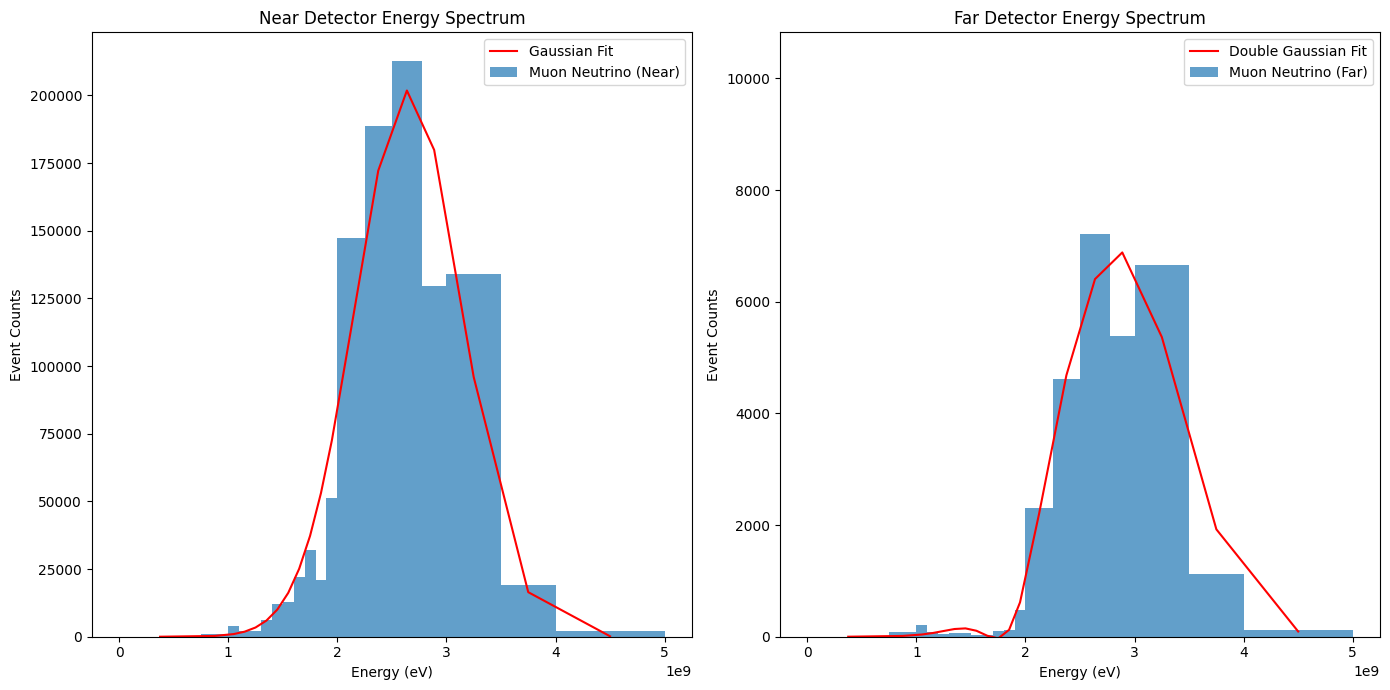

In [10]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from NuOscProbExact.src.oscprob3nu import probabilities_3nu
from NuOscProbExact.src.hamiltonians3nu import hamiltonian_3nu_vacuum_energy_independent, hamiltonian_3nu_matter
from NuOscProbExact.src.globaldefs import *

# Parameters
Length_near = 1  # Near detector distance in km
Length_far = 810  # Far detector distance in km

# Gaussian energy distribution
mean_energy = 2.5e9  # Mean energy in eV
sigma_energy = 0.5e9  # Standard deviation in eV
energies = np.random.normal(mean_energy, sigma_energy, 1000)

# Initialize vacuum Hamiltonian
h_vacuum_energy_indep = hamiltonian_3nu_vacuum_energy_independent(S12_NO_BF, S23_NO_BF, S13_NO_BF, DCP_NO_BF, D21_NO_BF, D31_NO_BF)

def compute_probabilities_matter(baseline):
    Prob_e, Prob_mu, Prob_tau = [], [], []
    for E in energies:
        # Matter Hamiltonian
        h_matter = hamiltonian_3nu_matter(h_vacuum_energy_indep, E, VCC_EARTH_CRUST)
        Pee, Pem, Pet, Pme, Pmm, Pmt, Pte, Ptm, Ptt = probabilities_3nu(h_matter, baseline * CONV_KM_TO_INV_EV)
        Prob_e.append(Pee)
        Prob_mu.append(Pmm)
        Prob_tau.append(Ptt)
    return np.array(Prob_e), np.array(Prob_mu), np.array(Prob_tau)

# Compute probabilities for ND and FD
Prob_e_near, Prob_mu_near, Prob_tau_near = compute_probabilities_matter(Length_near)
Prob_e_far, Prob_mu_far, Prob_tau_far = compute_probabilities_matter(Length_far)

# Events for ND and FD
total_events_near = 1000
total_events_far = 100

# Poisson-distributed counts
counts_mu_near = np.random.poisson(Prob_mu_near * total_events_near)
counts_mu_far = np.random.poisson(Prob_mu_far * total_events_far)

# Bin edges and centers for accurate plotting
bin_edges = np.array([0, 0.75, 1.0, 1.1, 1.2, 1.3, 1.4, 1.5, 1.6, 1.7, 1.8, 1.9, 2.0, 2.25, 2.5, 2.775, 3, 3.5, 4, 5]) * 1e9  # in eV
bin_centers = 0.5 * (bin_edges[1:] + bin_edges[:-1])

# Histograms for ND and FD
hist_near, _ = np.histogram(energies, bins=bin_edges, weights=counts_mu_near)
hist_far, _ = np.histogram(energies, bins=bin_edges, weights=counts_mu_far)

# Gaussian fitting function
def gaussian(x, A, mu, sigma):
    return A * np.exp(-(x - mu)**2 / (2 * sigma**2))

# Double Gaussian fitting for FD
def double_gaussian(x, A1, mu1, sigma1, A2, mu2, sigma2):
    return gaussian(x, A1, mu1, sigma1) + gaussian(x, A2, mu2, sigma2)

# Fit ND histogram
popt_near, _ = curve_fit(gaussian, bin_centers, hist_near, p0=[np.max(hist_near), mean_energy, sigma_energy])

# Fit FD histogram with double Gaussian
popt_far, _ = curve_fit(double_gaussian, bin_centers, hist_far,
                        p0=[np.max(hist_far) / 2, mean_energy * 0.9, sigma_energy,
                            np.max(hist_far) * 15, mean_energy * 1.1, sigma_energy * 2])

# Plot results
plt.figure(figsize=(14, 7))

# Near detector plot
plt.subplot(1, 2, 1)
plt.bar(bin_centers, hist_near, width=np.diff(bin_edges), align='center', alpha=0.7, label='Muon Neutrino (Near)')
plt.plot(bin_centers, gaussian(bin_centers, *popt_near), 'r-', label='Gaussian Fit')
plt.xlabel('Energy (eV)')
plt.ylabel('Event Counts')
plt.title('Near Detector Energy Spectrum')
plt.legend()

# Far detector plot
plt.subplot(1, 2, 2)
plt.bar(bin_centers, hist_far, width=np.diff(bin_edges), align='center', alpha=0.7, label='Muon Neutrino (Far)')
plt.plot(bin_centers, double_gaussian(bin_centers, *popt_far), 'r-', label='Double Gaussian Fit')
plt.xlabel('Energy (eV)')
plt.ylabel('Event Counts')
plt.title('Far Detector Energy Spectrum')
plt.legend()
plt.ylim(0, np.max(hist_far) * 1.5)

plt.tight_layout()
plt.show()

# Adjust starting parameters for ND and use the fitted Gaussian for comparison with FD.


Fitted parameters for ND: Amplitude = 212.7669270113613, Mean = 1.80441882366361, Sigma = 0.5254484170934041
Fitted parameters for FD: Amplitude = 13.876745900421612, Mean = 2.211417891177606, Sigma = 0.4952413589535657


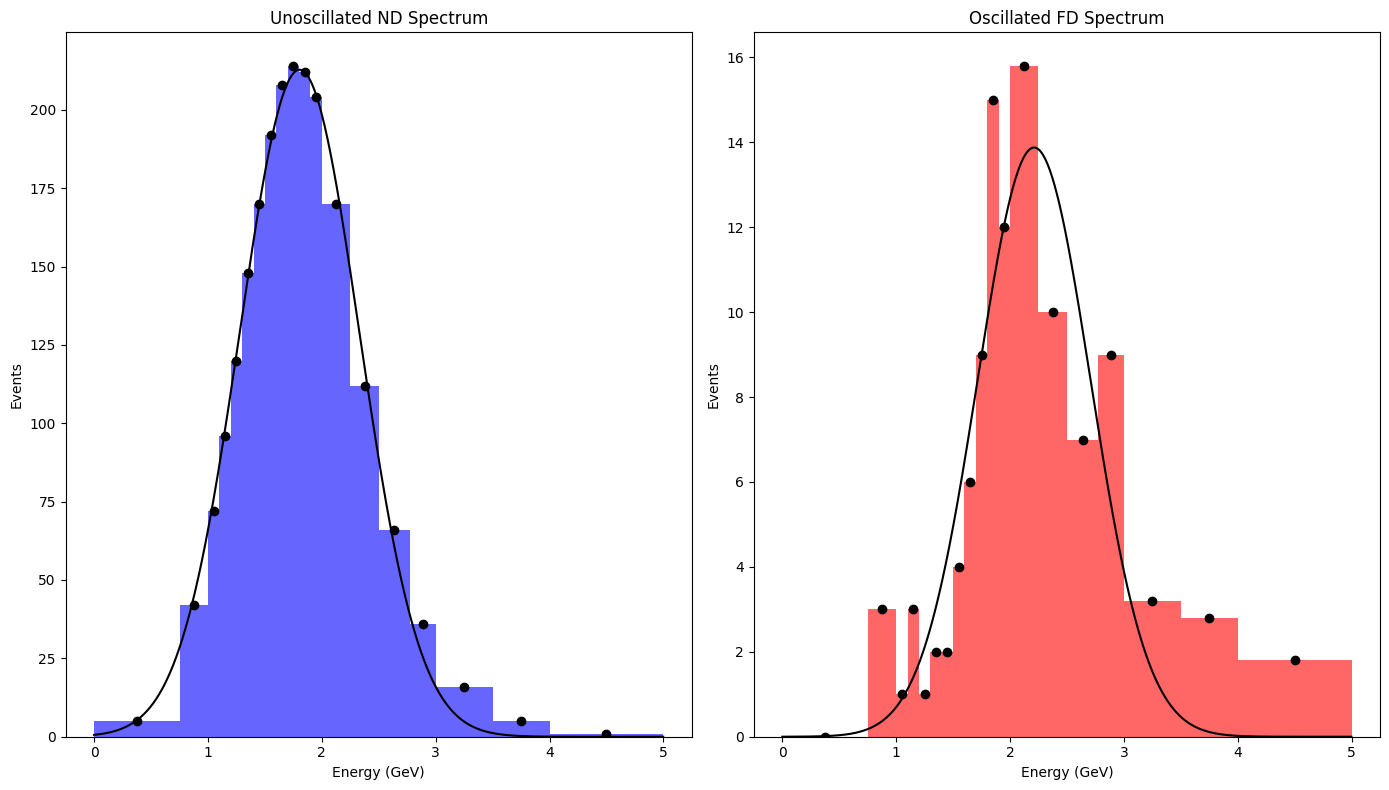

In [2]:
import sys
sys.path.append(r"c:/Users/Raees/Desktop/stuff/NuOscProbExact/src")

import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

# Gaussian function
def gaus(x, p0, p1, p2):
    return p0 * np.exp(-0.5 * ((x - p1)**2) / (p2**2))

# Parameters and data
bin_centers = np.array([0.375, 0.875, 1.05, 1.15, 1.25, 1.35, 1.45, 1.55, 1.65, 1.75, 1.85, 1.95, 2.125, 2.375, 2.6375, 2.8875, 3.25, 3.75, 4.5])
bin_edges = np.array([0, 0.75, 1.0, 1.1, 1.2, 1.3, 1.4, 1.5, 1.6, 1.7, 1.8, 1.9, 2.0, 2.25, 2.5, 2.775, 3, 3.5, 4, 5])
counts_nd = np.array([5, 42, 72, 96, 120, 148, 170, 192, 208, 214, 212, 204, 170, 112, 66, 36, 16, 5, 1])
counts_fd = np.array([0, 3, 1, 3, 1, 2, 2, 4, 6, 9, 15, 12, 15.8, 10, 7, 9, 3.2, 2.8, 1.8])

# Initial guesses for Gaussian fits
initial_guess_nd = [140, 2, 0.5]
initial_guess_fd = [8, 2, 0.5]

# Curve fitting
popt_nd, _ = curve_fit(gaus, bin_centers, counts_nd, p0=initial_guess_nd)
popt_fd, _ = curve_fit(gaus, bin_centers, counts_fd, p0=initial_guess_fd)

print(f"Fitted parameters for ND: Amplitude = {popt_nd[0]}, Mean = {popt_nd[1]}, Sigma = {popt_nd[2]}")
print(f"Fitted parameters for FD: Amplitude = {popt_fd[0]}, Mean = {popt_fd[1]}, Sigma = {popt_fd[2]}")

# Plotting
fig, axs = plt.subplots(1, 2, figsize=(14, 8))
x = np.arange(0, 5, 0.001)

# ND Spectrum
axs[0].hist(bin_edges[:-1], bin_edges, weights=counts_nd, alpha=0.6, color='blue')
axs[0].scatter(bin_centers, counts_nd, color='black')
axs[0].plot(x, gaus(x, *popt_nd), color='black')
axs[0].set_title("Unoscillated ND Spectrum")
axs[0].set_xlabel("Energy (GeV)")
axs[0].set_ylabel("Events")

# FD Spectrum
axs[1].hist(bin_edges[:-1], bin_edges, weights=counts_fd, alpha=0.6, color='red')
axs[1].scatter(bin_centers, counts_fd, color='black')
axs[1].plot(x, gaus(x, *popt_fd), color='black')
axs[1].set_title("Oscillated FD Spectrum")
axs[1].set_xlabel("Energy (GeV)")
axs[1].set_ylabel("Events")

plt.tight_layout()
plt.show()


Fitted parameters for FD: Amplitude = 13.876745900421612, Mean = 2.211417891177606, Sigma = 0.4952413589535657


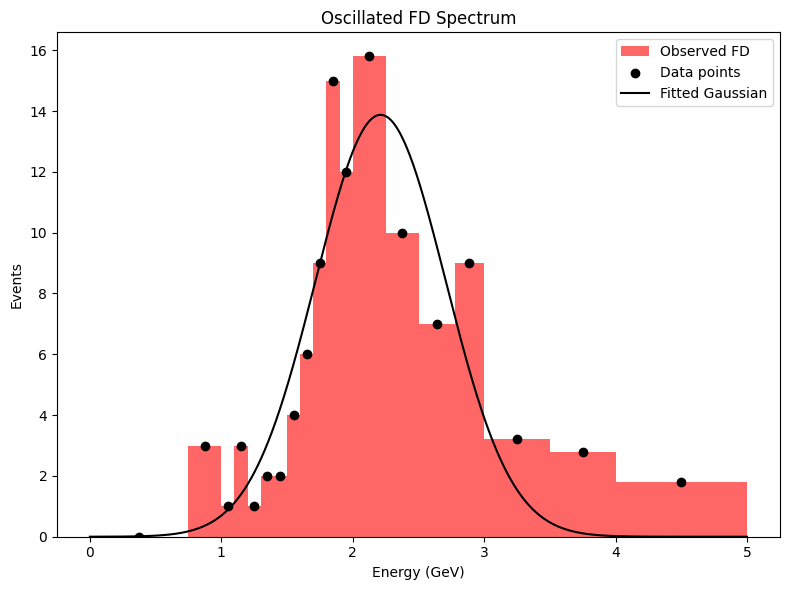

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

# Gaussian function
def gaus(x, p0, p1, p2):
    return p0 * np.exp(-0.5 * ((x - p1)**2) / (p2**2))

# FD Parameters and data
bin_centers_fd = np.array([0.375, 0.875, 1.05, 1.15, 1.25, 1.35, 1.45, 1.55, 1.65, 1.75, 1.85, 1.95, 2.125, 2.375, 2.6375, 2.8875, 3.25, 3.75, 4.5])
bin_edges_fd = np.array([0, 0.75, 1.0, 1.1, 1.2, 1.3, 1.4, 1.5, 1.6, 1.7, 1.8, 1.9, 2.0, 2.25, 2.5, 2.775, 3, 3.5, 4, 5])
counts_fd = np.array([0, 3, 1, 3, 1, 2, 2, 4, 6, 9, 15, 12, 15.8, 10, 7, 9, 3.2, 2.8, 1.8])

# Initial guess for Gaussian fit
initial_guess_fd = [8, 2, 0.5]

# Curve fitting
popt_fd, _ = curve_fit(gaus, bin_centers_fd, counts_fd, p0=initial_guess_fd)

print(f"Fitted parameters for FD: Amplitude = {popt_fd[0]}, Mean = {popt_fd[1]}, Sigma = {popt_fd[2]}")

# Plotting FD Spectrum
x = np.arange(0, 5, 0.001)
plt.figure(figsize=(8, 6))

plt.hist(bin_edges_fd[:-1], bin_edges_fd, weights=counts_fd, alpha=0.6, color='red', label="Observed FD")
plt.scatter(bin_centers_fd, counts_fd, color='black', label="Data points")
plt.plot(x, gaus(x, *popt_fd), color='black', label="Fitted Gaussian")

plt.title("Oscillated FD Spectrum")
plt.xlabel("Energy (GeV)")
plt.ylabel("Events")
plt.legend()
plt.tight_layout()
plt.show()


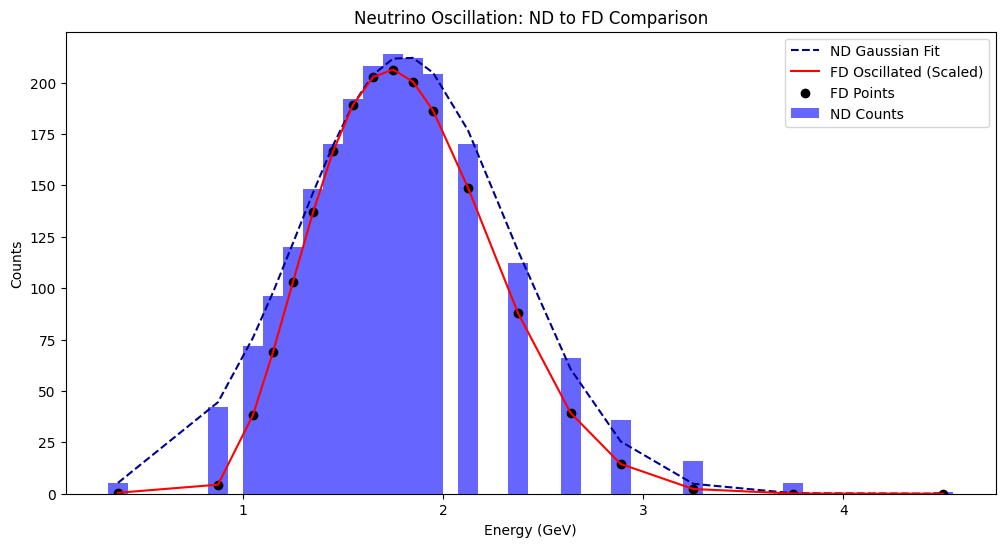

In [7]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

# Define Gaussian
def gaus(x, amplitude, mean, sigma):
    return amplitude * np.exp(-0.5 * ((x - mean) / sigma) ** 2)

# Oscillation probability formula
def osc_prob(E, L, theta, delta_m2):
    return np.sin(2 * theta) ** 2 * np.sin(1.27 * delta_m2 * L / E) ** 2

# Inputs
bin_centers = np.array([0.375, 0.875, 1.05, 1.15, 1.25, 1.35, 1.45, 1.55, 1.65, 1.75, 1.85, 1.95, 2.125, 2.375, 2.6375, 2.8875, 3.25, 3.75, 4.5])
counts_nd = np.array([5, 42, 72, 96, 120, 148, 170, 192, 208, 214, 212, 204, 170, 112, 66, 36, 16, 5, 1])
length_nd = 1  # [km]
length_fd = 810  # [km]

# Fit Gaussian to ND
popt_nd, _ = curve_fit(gaus, bin_centers, counts_nd, p0=[140, 2, 0.5])

# Oscillation parameters
theta = np.pi / 4  # Maximal mixing
delta_m2 = 2.4e-3  # Mass-squared difference (eV^2)

# Compute oscillation probabilities for FD
prob_fd = osc_prob(bin_centers, length_fd, theta, delta_m2)

# Apply scale factor and oscillation to ND Gaussian fit for FD
scaled_fd = gaus(bin_centers, *popt_nd) * prob_fd

# Plot results
plt.figure(figsize=(12, 6))
plt.bar(bin_centers, counts_nd, width=0.1, label="ND Counts", alpha=0.6, color="blue")
plt.plot(bin_centers, gaus(bin_centers, *popt_nd), label="ND Gaussian Fit", color="darkblue", linestyle="--")
plt.plot(bin_centers, scaled_fd, label="FD Oscillated (Scaled)", color="red")
plt.scatter(bin_centers, scaled_fd, color="black", label="FD Points")
plt.xlabel("Energy (GeV)")
plt.ylabel("Counts")
plt.legend()
plt.title("Neutrino Oscillation: ND to FD Comparison")
plt.show()
